In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

#### constants

In [2]:
c = 299792458.0  #[m/s], speed of light
h = 6.62607015 * 10**(-34) #[Js], planck constant 
hbar = h / (2 * np.pi) #[Js], reduced planck consant
meKg = 9.1093837015 * 10**(-31) #[kg], electron mass
meKeV = 511 #[keV]electron mass in kev
g = 1/np.pi #coverage function, uniform on [0, pi]
t = np.linspace(0, np.pi, 1000) #array of the possible scattering angles
na= 6.023e+23 #[atoms/mole], Avogadro number

#### simulation

In [3]:
class simulation:
    def __init__(self, isotope, energyPeak, halfLife, mass, molarMass, horizontal, depth, soilDensity, soilMAC, detRadius, detectionTime, mu):
        #parameters of the simulation
        self.isotope = isotope #type of isotope
        self.energyPeak = energyPeak #energy of the initial gamma photons
        self.halfLife = halfLife #half life in years
        self.mass = mass #radioactive source mass
        self.molarMass = molarMass #isotope molar mass
        self.horizontal = horizontal #horizontal distance source-detector
        self.depth = depth #source depth in the soil
        self.soilDensity = soilDensity #density of the soil
        self.soilMAC = soilMAC #soil mass absorption coefficient
        self.detRadius = detRadius #side length of the detector
        self.detectionTime = detectionTime #time of acquisition
        self.mu = mu #mean value of the rv (exponential) describing the number of scattering event  
   
    def radioSource(self):
        halfLifeS = self.halfLife*365.24*23.93*3600 #half lie expressed in seconds
        decayConstant = np.log(2)/halfLifeS 
        nAtoms = (self.mass*na)/self.molarMass
        A = decayConstant * nAtoms
        activity = round(A, 2) #[Bq], activity of the source 
        return activity
    
    def environment(self):
        soilAbs = self.soilDensity * self.soilMAC #soil absorption coefficient
        detCrossSection = self.detRadius**2 #[m^2] active detector area for photons collection
        distance = (self.horizontal**2 + self.depth**2)**0.5 #[m] average source-detector distance
        gammaIntensity = (detCrossSection*np.exp(-(distance*soilAbs))*self.radioSource())/(4*np.pi*distance**2)#n of photons reaching the detector
        gammaInteracting = round(gammaIntensity*self.detectionTime) #n of photons interacting with the detector in the detection time
        return [gammaInteracting, distance]
    
    #toymodel: photoelectric vs compton cross section as a function of photon energy
    def crossSectionRatio(self, energy): 
        return .25*np.exp(-(1/300)*energy) 

    def firstInteraction(self): #function describing the first interaction the photons
        gammaPh = round(self.environment()[0]*self.crossSectionRatio(self.energyPeak)) #662 keV gamma undergoing photoelectric effect
        gammaCompton = round(self.environment()[0]-gammaPh) #662 keV gamma undergoing compton effect 
        return [gammaPh, gammaCompton]
  
    def omegaFunction(self): #angular frequency of the scattered photon
        E = self.energyPeak*1000*1.602176634*10**(-19) #[J], initial photons energy in joule
        omega = E / hbar #[1/s], angular frequency
        return omega

    def R(self): #constant R, function of the angular frequency
        return hbar * self.omegaFunction()/(meKg * c**2) #constant R
        
    def I(self, angle): #function I(theta)
        return -np.cos(angle) / self.R()**2 + \
               np.log(1 + self.R() * (1 - np.cos(angle))) * (1/self.R() - 2/self.R()**2 - 2/self.R()**3) - \
               1 / (2 * self.R() * (1 + self.R() * (1 - np.cos(angle)))**2) + \
               1 / (1 + self.R() * (1 - np.cos(angle))) * (-2/self.R()**2 - 1/self.R()**3)

    def knpdf(self, angles): #the klein-nishina pdf
        omegaPrime = self.omegaFunction()/(1+(hbar*self.omegaFunction()/(meKg*c**2))*(1-np.cos(angles)))
        return (1/(self.I(np.pi)-self.I(0))) * (omegaPrime/self.omegaFunction())**2 * (self.omegaFunction()/omegaPrime + \
                omegaPrime/self.omegaFunction() -(np.sin(angles)**2))*np.sin(angles)

    #acceptance-rejection method to sample scattering angles from the klein-nishina pdf:
    def rejectionSampling(self): 
        samples = []
        sample = 0
        M = np.max(self.knpdf(t))/g 
        while True:
            x = np.random.uniform(0, np.pi)  #uniform sampling [0, pi]
            u = np.random.uniform(0, 1)  #uniform sampling [0, 1]
            if u <= self.knpdf(x) / (M * g): #acceptance-rejection algorithm
                sample = x
                break
        return sample

    def knSamplingPlot(self): #plot of the klein-nishina pdf alongside the simulated data
        thetaSamples = []
        #for each photon undergoing compton scattering, a scattering angle is sampled
        for _ in range(self.firstInteraction()[1]):
            thetaSample = self.rejectionSampling()
            thetaSamples.append(thetaSample)
        knpdf = self.knpdf(t) #knpdf computed in the interval [0, pi]
        fig = plt.figure(facecolor=(1,1,1)) 
        plt.hist(thetaSamples, bins=1000, density=True, label='θ sampling', histtype='stepfilled', color='#007be8')
        plt.plot(t, knpdf, label='klein-nishina PDF', color='red', linewidth=2)
        plt.legend()
        plt.xlabel('θ')
        plt.title('compton scattering angles')
        fig.set_figheight(2.5)
        fig.set_figwidth(5)
        plt.show()
        plt.close(fig)

    def energyLoss(self, gammaEnergy): #energy lost by a photon in a single scattering event
        return gammaEnergy*(1-(1/(1 + ((gammaEnergy/meKeV) * (1 - np.cos(self.rejectionSampling()))))))

    def resolution(self, energy): 
        detResolution = 1.714824*energy**(-0.504) #resolution of the detector as a function of energy
        FWHM = energy * detResolution #FWHM of the detector as a function of energy
        #the measure of the energy deposited by each photon, is normally distributed around its true value; sigma, which depends on energy, is the variance of such ditribution
        sigma = FWHM / 2.335 
        return sigma
        
    def compton(self): #function implementing the compton scattering process (extensively commented)
        #toy model -> probability of the number of scattering events; for each of the initial photon undergoing cs, the number of total cs events before exiting (without, atm, taking into account photoelectric effects) the detector is simulated
        scatteringEventsNumber = np.random.exponential(self.mu, self.firstInteraction()[1]).astype(int)+2 
        scatteringSteps = []
        deposited = []
        phAfterCompton = 0 
        for i in scatteringEventsNumber: #i is the index of the photons undergoing cs
            energyDep = np.zeros(i) #array (one for each photon) which will contain the energy deposited during each cs event
            energyRem = np.zeros(i) #array (one for each photon) which will contain the energy remaining after each cs event
            energyRem[0] = self.energyPeak #the energy remaining for each photon BEFORE the first scattering event (which, of course, corresponds to the photon’s total energy)
            #after each scattering event, the photon retains an energy ‘energyRem’; 
            for j in range(i-1): #in this cycle, the probability of a new scattering event occurring, is calculated based on each energyRem and therefore after each scattering event, 
                #the higher the remaining energy at the step j+i, the higher the probability of a further cs to occur; 
                if self.crossSectionRatio(energyRem[j+1]) < np.random.uniform(0, 1): #this process is implemented by sampling uniformly between 0 and 1 and confronting the sample with the cs-pe cross section at the corresponding energy
                    energyDep[j] = self.energyLoss(energyRem[j]) #if a further cs event is expected to happen, the energy deposited is given by the function energyLoss computed with the value of the photon remaing energy at the previous step
                    energyRem[j+1] = energyRem[j] - energyDep[j] #the remaining energy of the photon after this second cs, is the initial energy before the second cs minus the energy deposited during the second cs
                else: #if a second cs does not take place, it means that the photon is absorbed by pe;
                    phAfterCompton += 1 #in this case, the number of photons undergoing photoelectric effect is increased by one
                    break #and the cycle stops -> all the initial energy of the photon is deposited, and we start with another photon; oteherwise the cycle will continue!!!
            scatteringSteps.append(energyDep) #list containg arrays, one for each photon, with energy deposited at each scattering step
        for i in scatteringSteps: 
            deposited.append(np.sum(i)) #total energy deposited by compton scattering by photon with index i
            depositedEnergies = np.array(deposited).astype(int) 
            depositedEnergies = depositedEnergies[depositedEnergies != 0]
        #each final energy deposited is measured with an uncertainty depending on the energy itself:
        for i in depositedEnergies: 
            #each measured deposited energy is distributed normally around its true value ("depositedEnergies at step i"), with variance computed with the function resolution depending on the energy "i". of course only 1 value is sampled
            i = np.random.normal(i, self.resolution(i), 1)
        #the compton function returns the energies deposited by the photons THAT HAVE LEFT the detector after a serie of compton scatterings, and the number of photons absorbed by photoelectric effect after 1 or more compton scatterings
        return [depositedEnergies, phAfterCompton] 

    #simulation of the photoelectric effect: the number of photons absorbed via the photoelectric effect is equal to the number of photons absorbed immediately plus the number of photons absorbed after one or more compton scatterings
    def photoelectric(self): 
        comptonData = self.compton()[1] #number of photons absorbed after one or more compton scatterings 
        #the photopeak is normally distributed around the initial gamma energy (in our case 662keV), with variance given by the resolution function computed at the ernergy peak
        phCounts = np.random.normal(self.energyPeak, self.resolution(self.energyPeak), self.firstInteraction()[1]+comptonData).astype(int) 
        return phCounts #array of the energy deposited via photoelectric effect!

    #plot of the famma spectrum
    def gammaSpectrum(self): 
        gammaSpec = np.concatenate((self.photoelectric(), self.compton()[0]), axis=None) #the arrays of the deposited energies (via cs and pe) are put together
        energies, counts = np.unique(gammaSpec, return_counts=True) #element of the two arrays corresponding to the same deposited energy are summed
        fig = plt.figure(facecolor=(1,1,1)) 
        fig.set_figheight(2.5)
        fig.set_figwidth(5)
        plt.plot(energies, counts, color='#007be8', linewidth=1.5)
        plt.xlabel('energy [keV]')
        plt.ylabel('counts')
        plt.title(r'cs137 $\gamma$ spectrum')
        ax = plt.gca()
        ax.set_yscale('log')
        plt.show()

    #plot of the θ sampling and klein-nishina distribution
    def comptonPlot(self):
        data = simulation.compton()[0]
        fig, ax = plt.subplots(figsize=(4, 2), facecolor=(1,1,1))
        plt.hist(data, bins=10000, label='θ sampling', color='#31A772', histtype='stepfilled', edgecolor='#31A772')
        ax.set_xlabel('energy')
        ax.set_ylabel('counts')
        ax.set_title('compton: energy deposited')
        ax.grid(linewidth=0.3)
        plt.show()

    #recap of the simulation with some usefull data
    def recap(self):
        comptonEdge = self.energyPeak*(1-(1/(1 + ((self.energyPeak/meKeV) * (1 - np.cos(np.pi))))))
        comptonEdge = round(comptonEdge, 2)
        print("isotope:", self.isotope)
        print("energy peak:", self.energyPeak, "keV")
        print("compton edge:", comptonEdge, "keV")
        print("isotope mass:", self.mass, "kg")
        print("source-detector distance:", self.environment()[1], "m")
        print("source activity:", self.radioSource(), "Bq")
        print("photons that initially undergo compton scattering:", self.firstInteraction()[1])
        print("photons absorbed immediatly by photoelectric effect:", self.firstInteraction()[0])
        print("photons absorbed by photoelectric effect after one or more Compton:", self.compton()[1])

#### running the simulation

In [4]:
#running the simulation: each of these parameters can be modified!
sim = simulation('cs137', #isotope
                 661.7, #[keV] cs137 energy peak
                 30, #[years] half-life
                 1.5e-9, #[g] mass
                 136.907, #[g/mole], cs137 molar mass
                 0, #[m], source-detector horizontal distance
                 0.1, #[m], source depth in the soil
                 1.3, #[g/cm^3], soil density
                 0.08045, #[cm^2/g], soil mass attenuation coefficient
                 0.102, #[m], detector side length
                 120, #[s], 2 minutes - detection time
                 3) #mean value of the exponential pdf of the number of compton events

#### $\theta$ sampling plot

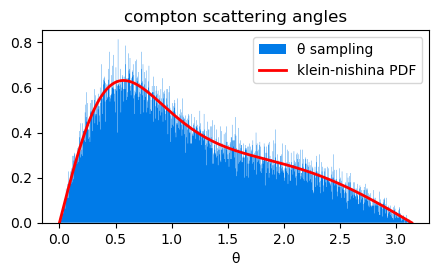

In [5]:
sim.knSamplingPlot()

#### full gamma spectrum

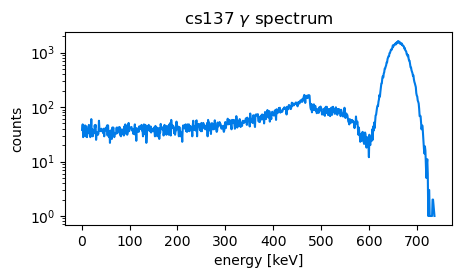

In [6]:
sim.gammaSpectrum()

In [ ]:
sim.recap()

isotope: cs137
energy peak: 661.7 keV
compton edge: 477.37 keV
isotope mass: 1.5e-09 kg
source-detector distance: 0.1 m
source activity: 4845.73 Bq
photons that initially undergo compton scattering: 46330
photons absorbed immediatly by photoelectric effect: 1312
